<a href="https://colab.research.google.com/github/meirBal/meir/blob/main/%D7%AA%D7%A8%D7%92%D7%95%D7%9C4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the Kaggle library
!pip install kaggle

In [ ]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download lakshmi25npathi/online-retail-dataset
!unzip online-retail-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset
License(s): other
100% 43.3M/43.3M [00:00<00:00, 117MB/s]

Archive:  online-retail-dataset.zip
  inflating: online_retail_II.xlsx   


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_excel("online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


#### get to know the data
explore the data using pandas tools.

- what types of columns do we have?
- do we have numerical or categorical features?
- do we have missing values?
- check for corrupted/unrealistic values
- do we have duplicates?

In [ ]:
# your code here...


missing and duplicate values

check "Quantity" column

check "Price" column

### Feature Engineering

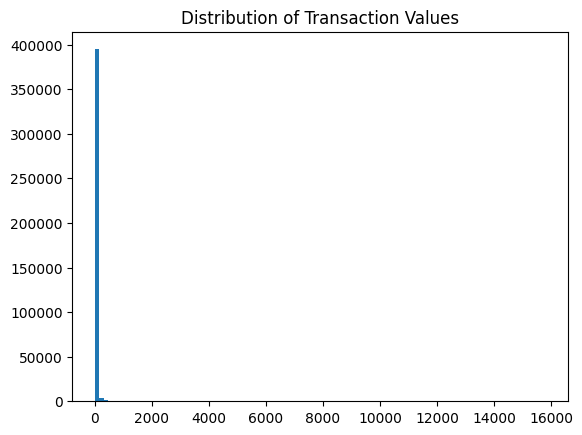

In [ ]:
# calculate the total price
df["TotalPrice"] = df["Quantity"] * df["Price"]
plt.hist(df["TotalPrice"], bins=100)
plt.title("Distribution of Transaction Values")
plt.show()

# Most transactions are small, but a few are extremely large (long-tail distribution)

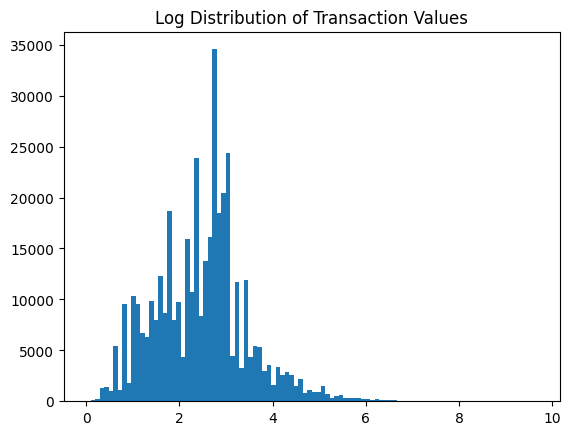

In [ ]:
plt.hist(np.log1p(df["TotalPrice"]), bins=100)
plt.title("Log Distribution of Transaction Values")
plt.show()

In [ ]:
# convert invoice date to datetime type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

extract features

In [ ]:
df["year"] = df["InvoiceDate"].dt.year
df["month"] = df["InvoiceDate"].dt.month
df["day"] = df["InvoiceDate"].dt.day
df["hour"] = df["InvoiceDate"].dt.hour
df["dayofweek"] = df["InvoiceDate"].dt.day_name()

In [ ]:
df["year"].unique()

array([2009, 2010], dtype=int32)

calculate the daily sales and plot them:

In [ ]:
# your code here:


explore the distribution of values in "Country" column

In [ ]:
# your code here:


Many countries with very few transactions! group them to handle Long Tail

In [ ]:
top_countries = df["Country"].value_counts().nlargest(5).index

df["Country_grouped"] = df["Country"].apply(
    lambda x: x if x in top_countries else "Other"
)

get the total revenue per country

In [ ]:
# your code here:


which country has the highest total prices on average

In [ ]:
df.groupby("Country_grouped")["TotalPrice"].mean().sort_values(ascending=False)

,Total Price
Country_grouped,
Netherlands,98.527988
EIRE,41.872499
Other,35.906972
France,26.798802
Germany,26.425820
United Kingdom,20.266270


- find the top 10 customers in terms of spending

In [ ]:
# your code here:


plot monthly revenue

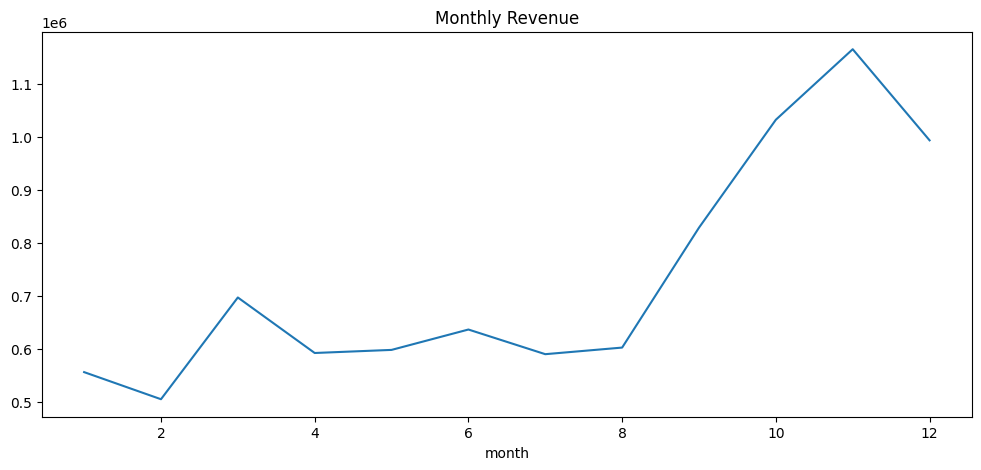

In [ ]:
monthly_sales = df.groupby("month")["TotalPrice"].sum()

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Revenue")
plt.show()

which days have on average the highest/lowest number of sales?

In [ ]:
df.groupby("dayofweek")["TotalPrice"].mean()

,Total Price
dayofweek,
Friday,25.374870
Monday,23.087961
Saturday,24.507625
Sunday,14.184015
Thursday,23.099653
Tuesday,24.200708
Wednesday,22.872787


which hours have the highest sales amounts on average?

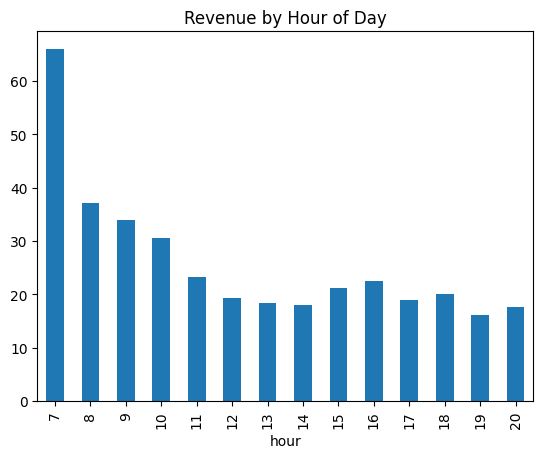

In [ ]:
df.groupby("hour")["TotalPrice"].mean().plot(kind="bar")
plt.title("Revenue by Hour of Day")
plt.show()

which are the 10 most popular products?

In [ ]:
df["StockCode"].value_counts().head(10)

,count
StockCode,
85123A,3107
85099B,1730
22423,1695
21212,1553
21232,1372


which are the 10 products that generated the highest revenue?

In [ ]:
df.groupby("StockCode")["TotalPrice"].sum().sort_values(ascending=False).head(10)

,Total Price
StockCode,
85123A,151339.16
22423,143727.60
M,98531.99
85099B,85257.45
84879,70291.03
POST,48741.08
21843,41457.64
48138,41223.56
84347,40156.05
